In [1]:
pip install pandas numpy matplotlib scikit-learn prophet notebook

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.75 requires requests_mock, which is not installed.
conda-repo-cli 1.0.75 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.75 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
conda-repo-cli 1.0.75 requires PyYAML==6.0.1, but you have pyyaml 6.0 which is incompatible.



  Obtaining dependency information for prophet from https://files.pythonhosted.org/packages/d9/9c/af59d9f30e9e72f2b36bd578a47a84c8fbf7f72c2d9771ef40ef16fb36eb/prophet-1.3.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for cmdstanpy>=1.0.4 from https://files.pythonhosted.org/packages/ef/04/7bbe85aa6abf99236cc657ceb5a629f63a82a01910a095533111ea3860f3/cmdstanpy-1.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for holidays<1,>=0.25 from https://files.pythonhosted.org/packages/f6/8a/e78033ccfd0c8068b35322202fda4a5f6d11f21d86d86c8fd6957619b156/holidays-0.94-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 165.2 kB/s eta 0:00:01
     ---------------------- --------------- 30.7/52.8 kB 187.9 kB/s eta 0:00:0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from prophet import Prophet

In [3]:
np.random.seed(0)

dates = pd.date_range(start='2024-01-01', periods=100)

data = pd.DataFrame({
    'ds': dates,
    'usage': np.random.randint(10, 100, 100)
})

data.head()

,ds,usage
0,2024-01-01,54
1,2024-01-02,57
2,2024-01-03,74
3,2024-01-04,77
4,2024-01-05,77


In [4]:
def categorize(x):
    if x < 30:
        return 0   # Low
    elif x < 70:
        return 1   # Medium
    else:
        return 2   # High

data['category'] = data['usage'].apply(categorize)

In [5]:
X = np.arange(len(data)).reshape(-1, 1)
y = data['category']

nb_model = GaussianNB()
nb_model.fit(X, y)

GaussianNB()

In [6]:
prophet_data = data[['ds', 'usage']].rename(columns={'usage': 'y'})

model = Prophet()
model.fit(prophet_data)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

16:08:36 - cmdstanpy - INFO - Chain [1] start processing
16:08:37 - cmdstanpy - INFO - Chain [1] done processing


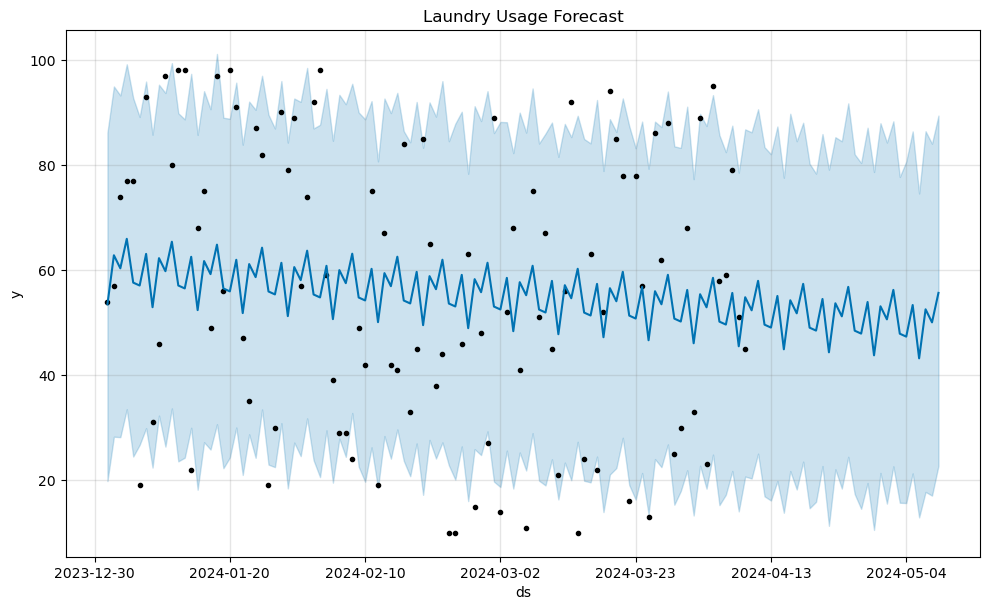

In [7]:
model.plot(forecast)
plt.title("Laundry Usage Forecast")
plt.show()

Enter number of future days to view: 23


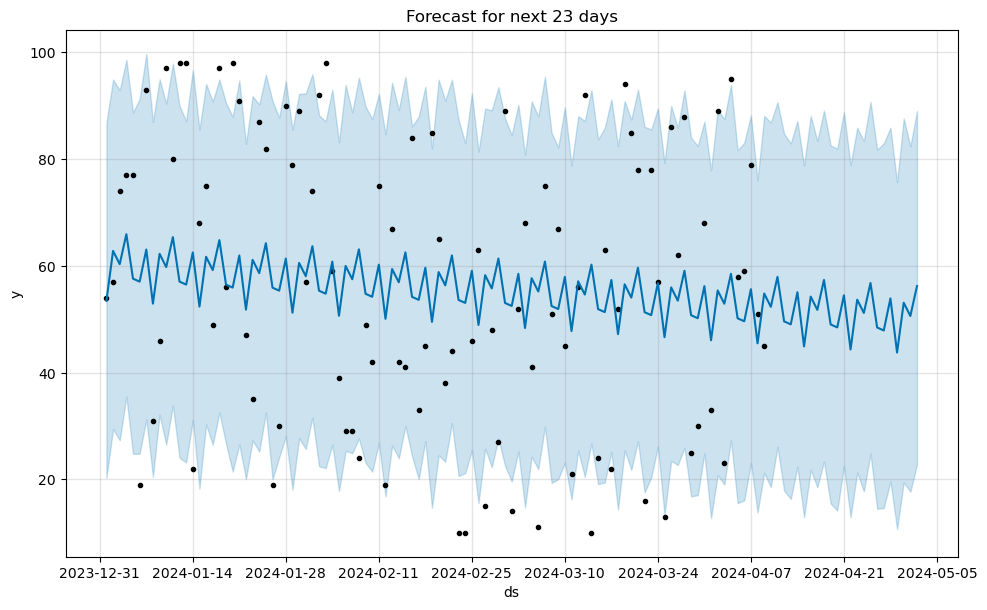

In [8]:
days = int(input("Enter number of future days to view: "))

future = model.make_future_dataframe(periods=days)
forecast = model.predict(future)

model.plot(forecast)
plt.title(f"Forecast for next {days} days")
plt.show()